In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# It is used to print all the rows and columns inside the dataset

# pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [3]:
df = pd.read_csv("../data/processed/cleaned_data_v1.csv")

In [4]:
df.head()

,transaction_id,customer_id,device_id,merchant_id,transaction_date,transaction_time,amount,payment_method,is_international,merchant_category,ip_address_risk_score,device_trust_score,txn_count_last_24h,avg_amount_last_24h,merchant_diversity_last_7d,device_change_flag,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,hour_of_day,day_of_week,is_weekend,is_fraud
0,1,1357,20937,720,2024-01-18,19:23:00,18780.52,WALLET,0,Travel,0.243550,0.116606,7,6055.25,3,0,0,NONE,0.769328,1,2,0.069502,19,3,0,0
1,2,4095,29542,764,2024-03-30,02:22:00,18955.06,CARD,0,Electronics,0.119761,0.030579,1,13366.74,5,0,1,OTP,0.468411,1,1,0.010010,2,5,1,0
2,3,3618,25236,671,2024-01-04,17:26:00,10743.34,UPI,0,Fashion,0.565367,0.183770,0,7359.14,4,0,0,PIN,0.464356,0,1,0.118434,17,3,0,0
3,4,2755,29904,624,2024-01-27,16:00:00,5054.75,CARD,0,Utilities,0.843842,0.717286,5,10923.57,6,0,0,PIN,0.635799,0,3,0.114947,16,5,1,0
4,5,2732,24151,501,2024-02-20,23:14:00,14799.50,CARD,0,Gaming,0.202402,0.041616,11,6027.72,10,1,0,OTP,0.684301,2,0,0.014550,23,1,0,0


## Traget Variable

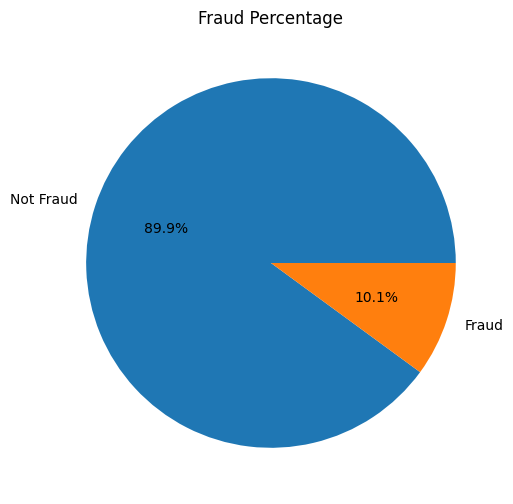

In [5]:
plt.figure(figsize=(8, 6))
plt.pie(df['is_fraud'].value_counts(), autopct='%1.1f%%',labels=['Not Fraud', 'Fraud'])
plt.title('Fraud Percentage')
plt.show()


### Target VS ID's

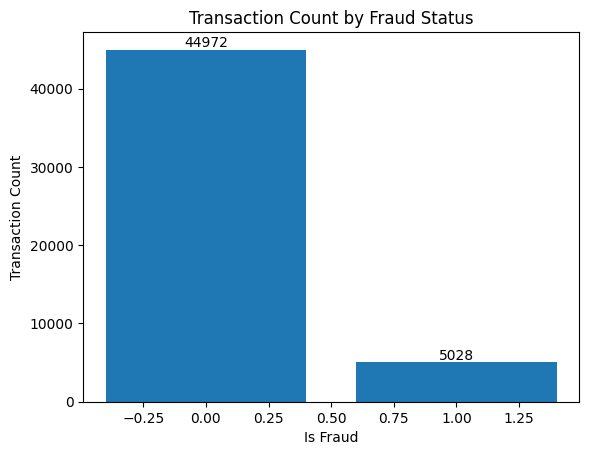

In [6]:
transaction_count = df.groupby('is_fraud')['transaction_id'].nunique().reset_index()
transaction_count.columns = ['is_fraud', 'count']
bars = plt.bar(transaction_count['is_fraud'], transaction_count['count'])
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Count')
plt.title('Transaction Count by Fraud Status')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,   # X position
        height,                            # Y position
        f'{int(height)}',                  # Text
        ha='center', 
        va='bottom'
    )
plt.show()

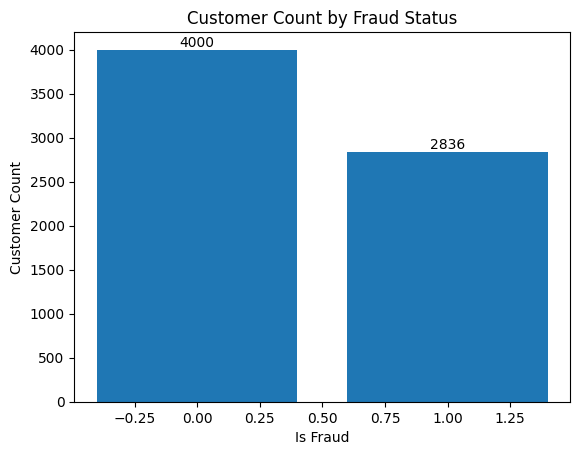

In [7]:
customer_count = df.groupby('is_fraud')['customer_id'].nunique().reset_index()
customer_count.columns = ['is_fraud', 'count']
bars = plt.bar(customer_count['is_fraud'], customer_count['count'])
plt.xlabel('Is Fraud')
plt.ylabel('Customer Count')
plt.title('Customer Count by Fraud Status')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,   # X position
        height,                            # Y position
        f'{int(height)}',                  # Text
        ha='center', 
        va='bottom'
    )
plt.show()

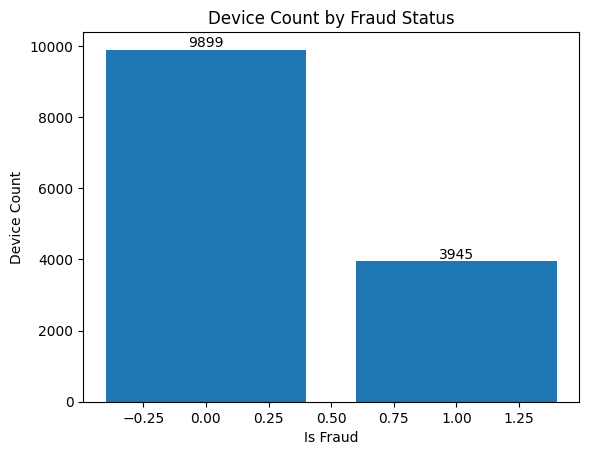

In [8]:
device_count = df.groupby('is_fraud')['device_id'].nunique().reset_index()
device_count.columns = ['is_fraud', 'count']
bars = plt.bar(device_count['is_fraud'], device_count['count'])
plt.xlabel('Is Fraud')
plt.ylabel('Device Count')
plt.title('Device Count by Fraud Status')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,   # X position
        height,                            # Y position
        f'{int(height)}',                  # Text
        ha='center', 
        va='bottom'
    )
plt.show()

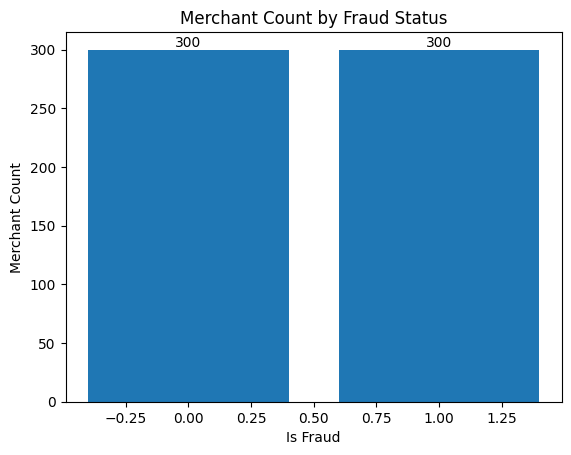

In [9]:
merchant_count = df.groupby('is_fraud')['merchant_id'].nunique().reset_index()
merchant_count.columns = ['is_fraud', 'count']
bars = plt.bar(merchant_count['is_fraud'], merchant_count['count'])
plt.xlabel('Is Fraud')
plt.ylabel('Merchant Count')
plt.title('Merchant Count by Fraud Status')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,   # X position
        height,                            # Y position
        f'{int(height)}',                  # Text
        ha='center', 
        va='bottom'
    )
plt.show()

### Target VS Timestamp

In [10]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

month_map = {1: "Jan", 2: "Feb", 3: "Mar"}
df['transaction_month'] = df['transaction_date'].dt.month.map(month_map)

In [11]:
mon_day = pd.pivot_table(
    data=df,
    index=df['transaction_date'].dt.day,
    columns=['transaction_month', 'is_fraud'],
    values='transaction_id',
    aggfunc='count',
    fill_value=0,
)
mon_day



transaction_month  Feb      Jan      Mar    
is_fraud             0   1    0   1    0   1
transaction_date                            
1                  509  55  524  46  483  67
2                  502  56  499  45  470  54
3                  488  55  486  56  495  48
4                  477  45  539  50  497  66
5                  484  64  531  60  527  59
6                  482  51  473  64  494  54
7                  458  57  489  68  460  55
8                  523  65  482  70  496  69
9                  485  36  489  64  495  68
10                 491  69  537  56  533  60
11                 504  58  516  54  462  66
12                 476  60  488  49  461  57
13                 496  50  464  53  485  60
14                 533  55  493  66  472  44
15                 559  50  417  35  493  58
16                 487  50  469  49  495  52
17                 499  61  496  53  476  57
18                 507  38  512  57  510  55
19                 494  65  505  47  514  50
20                 533  63  529  56  499  49
21                 516  52  485  60  518  58
22                 516  56  501  61  482  58
23                 535  50  509  48  507  55
24                 453  80  523  53  478  61
25                 490  50  497  59  478  60
26                 515  42  521  45  484  54
27                 499  62  505  56  552  66
28                 555  54  466  54  525  66
29                 516  53  545  50  525  45
30                   0   0  532  66  502  54
31                   0   0  500  51    0   0

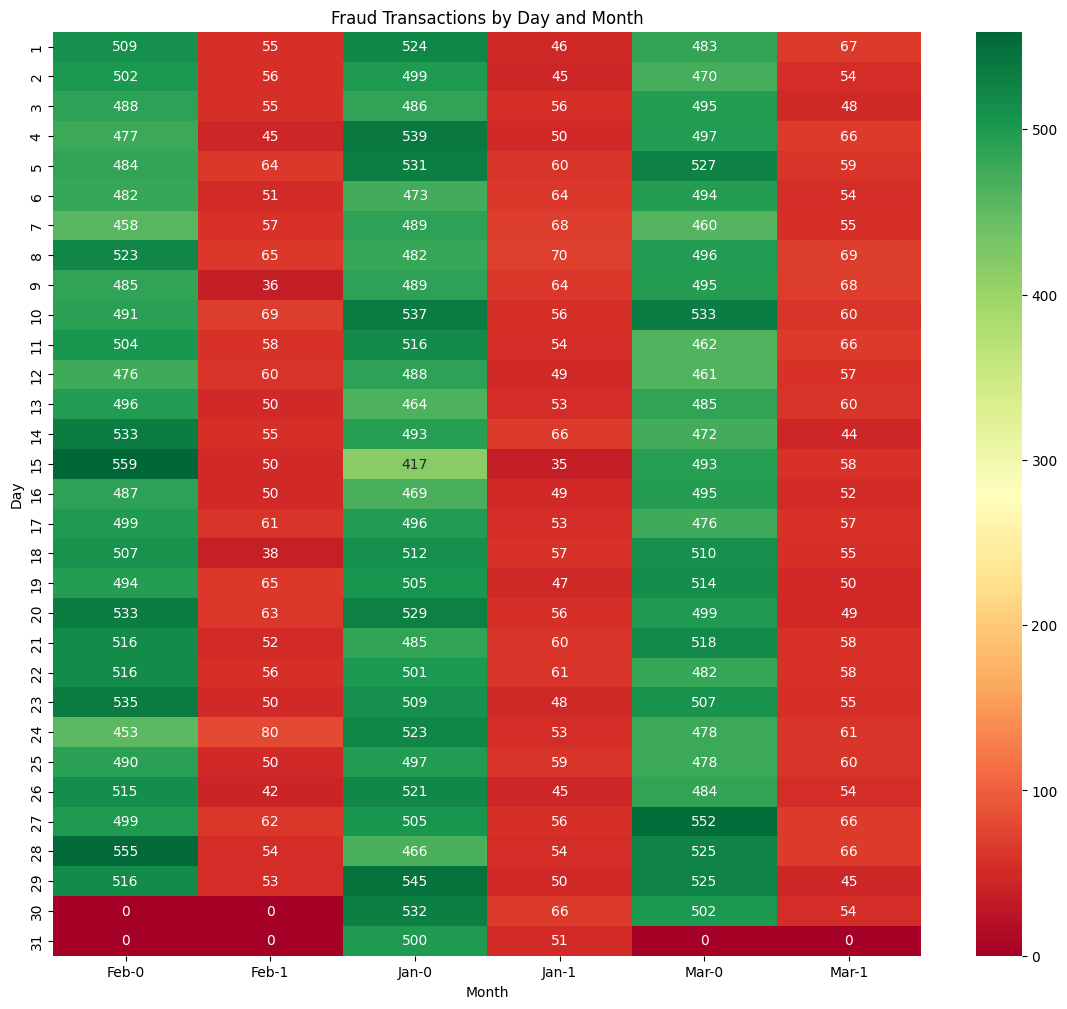

In [12]:
plt.figure(figsize=(14, 12))
sns.heatmap(mon_day, cmap="RdYlGn", annot=True, fmt="d")

plt.title("Fraud Transactions by Day and Month")
plt.xlabel("Month")
plt.ylabel("Day")
plt.show()

<Figure size 1200x600 with 0 Axes>

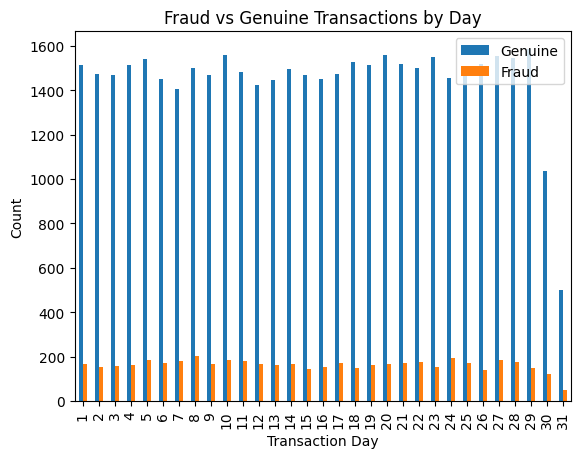

is_fraud,0,1
transaction_date,,
1,1516,168
2,1471,155
3,1469,159
4,1513,161
5,1542,183
6,1449,169
7,1407,180
8,1501,204
9,1469,168


In [13]:
data_df = df.groupby(df['transaction_date'].dt.day)['is_fraud'].value_counts().unstack(fill_value=0)
plt.figure(figsize=(12, 6))
data_df.plot(kind='bar')
plt.xlabel('Transaction Day')
plt.ylabel('Count')
plt.title('Fraud vs Genuine Transactions by Day')
plt.legend(['Genuine', 'Fraud'])
plt.show()
data_df

### Traget VS Amount

In [14]:
df['amount'].describe()

count    50000.000000
mean     10015.213203
std       5756.852793
min         50.510000
25%       5007.712500
50%       9971.515000
75%      15017.282500
max      19999.080000
Name: amount, dtype: float64

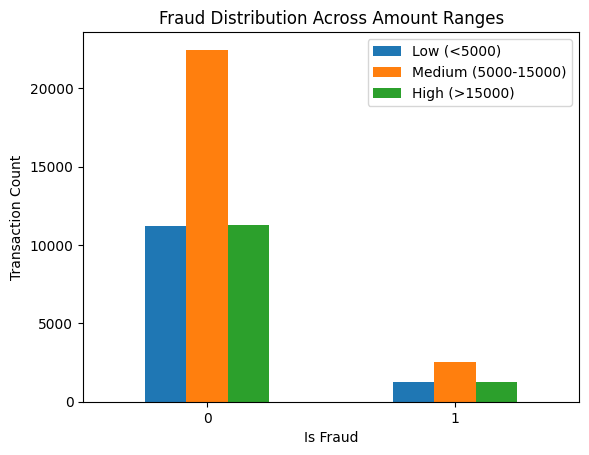

In [15]:
low = df[df['amount'] < 5000]
medium = df[df['amount'].between(5000, 15000)]
high = df[df['amount'] > 15000]

low_counts = low['is_fraud'].value_counts()
medium_counts = medium['is_fraud'].value_counts()
high_counts = high['is_fraud'].value_counts()

combined = pd.DataFrame({
    'Low (<5000)': low_counts,
    'Medium (5000-15000)': medium_counts,
    'High (>15000)': high_counts
}).fillna(0)

combined

combined.plot(kind='bar')

plt.xlabel('Is Fraud')
plt.ylabel('Transaction Count')
plt.title('Fraud Distribution Across Amount Ranges')
plt.xticks(rotation=0)
plt.show()

### Merchant Fraud Rate

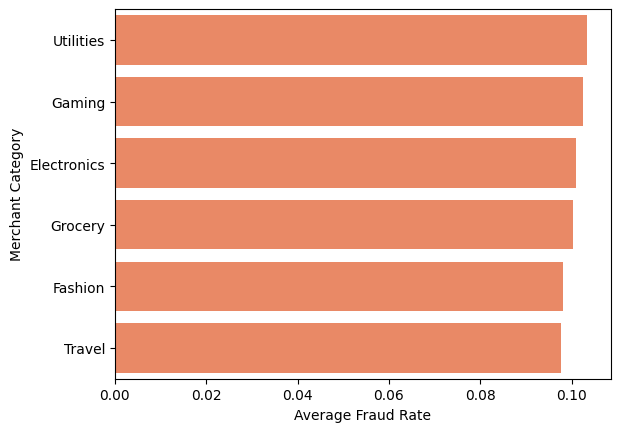

In [41]:
merch_fraud = df.groupby('merchant_category')['is_fraud'].mean().reset_index()
merch_fraud = merch_fraud.sort_values(by='is_fraud', ascending=False)

sns.barplot(data=merch_fraud,x='is_fraud',y='merchant_category', color='coral')

plt.xlabel('Average Fraud Rate')
plt.ylabel('Merchant Category')
plt.show()

### Target VS Payment Method

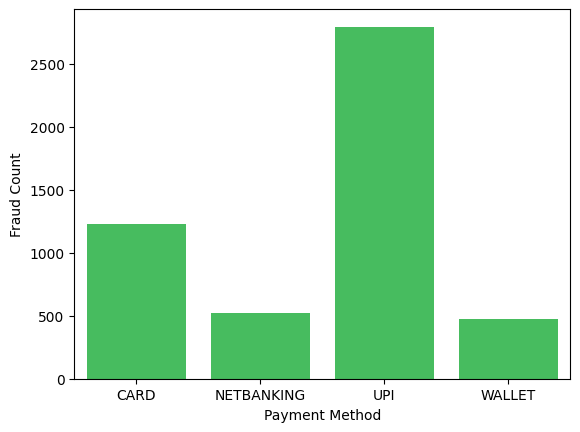

In [59]:
fraud_df = df[df['is_fraud'] == 1]
value_count = fraud_df.groupby('payment_method')['is_fraud'].value_counts().reset_index()
sns.barplot(data=value_count, x='payment_method', y='count', color='#34CF53')
plt.xlabel('Payment Method')
plt.ylabel('Fraud Count')
plt.show()

### Payment Method and Authentication Method

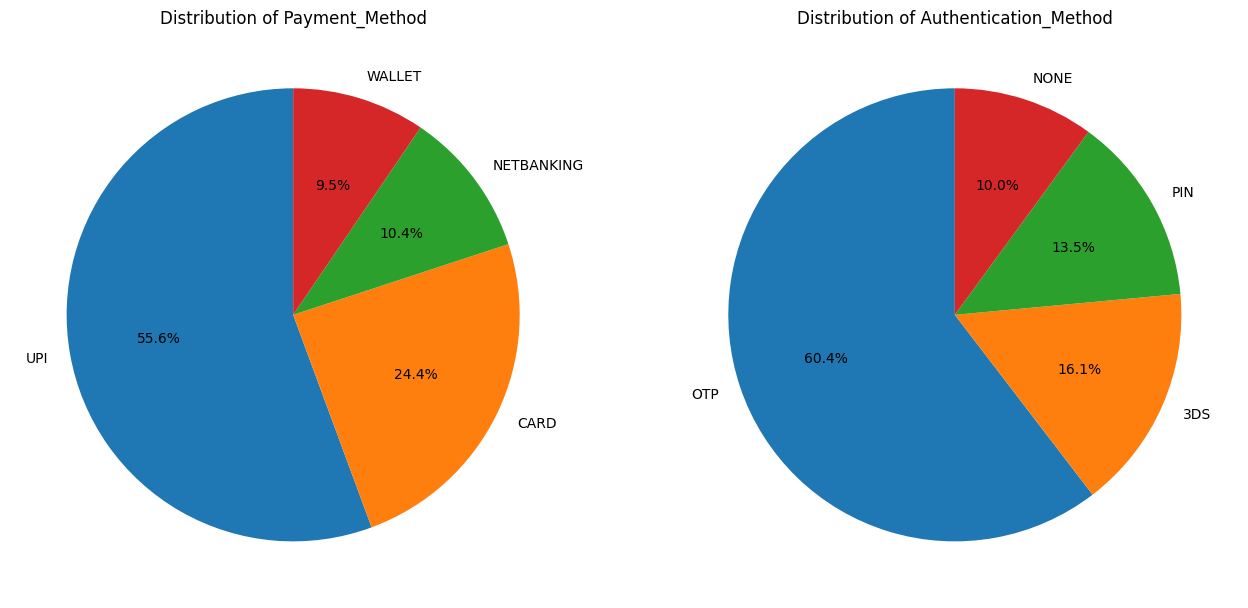

In [60]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for fraud payment_method and authentication_method
for idx, col in enumerate(['payment_method','authentication_method'], 1):
    ax = plt.subplot(2, 3, idx)
    fraud_df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {col.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### Observation

* Among fraudulent transactions, UPI is the most commonly used payment method (≈55.6%), followed by Card payments (≈24.4%).

* Net banking (≈10.4%) and Wallets (≈9.5%) contribute a smaller share of fraud cases.

* Regarding authentication, OTP-based verification is still the most used method in fraud cases (≈60.4%), followed by 3DS (≈16.1%) and PIN (≈13.5%).

* About 10% of fraudulent transactions occur without any authentication, which may indicate higher vulnerability and potential security gaps.

In [61]:
df.head()

,transaction_id,customer_id,device_id,merchant_id,transaction_date,transaction_time,amount,payment_method,is_international,merchant_category,ip_address_risk_score,device_trust_score,txn_count_last_24h,avg_amount_last_24h,merchant_diversity_last_7d,device_change_flag,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,hour_of_day,day_of_week,is_weekend,is_fraud,transaction_month,transaction_month_num
0,1,1357,20937,720,2024-01-18,19:23:00,18780.52,WALLET,0,Travel,0.243550,0.116606,7,6055.25,3,0,0,NONE,0.769328,1,2,0.069502,19,3,0,0,Jan,1
1,2,4095,29542,764,2024-03-30,02:22:00,18955.06,CARD,0,Electronics,0.119761,0.030579,1,13366.74,5,0,1,OTP,0.468411,1,1,0.010010,2,5,1,0,Mar,3
2,3,3618,25236,671,2024-01-04,17:26:00,10743.34,UPI,0,Fashion,0.565367,0.183770,0,7359.14,4,0,0,PIN,0.464356,0,1,0.118434,17,3,0,0,Jan,1
3,4,2755,29904,624,2024-01-27,16:00:00,5054.75,CARD,0,Utilities,0.843842,0.717286,5,10923.57,6,0,0,PIN,0.635799,0,3,0.114947,16,5,1,0,Jan,1
4,5,2732,24151,501,2024-02-20,23:14:00,14799.50,CARD,0,Gaming,0.202402,0.041616,11,6027.72,10,1,0,OTP,0.684301,2,0,0.014550,23,1,0,0,Feb,2


### International Fraud Count

<Axes: xlabel='is_international', ylabel='count'>

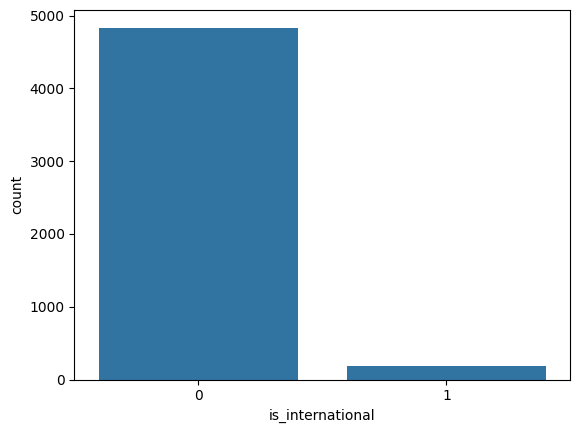

In [70]:
fraud_int_count = fraud_df.groupby('is_international')['is_fraud'].value_counts().reset_index()
sns.barplot(data=fraud_int_count, x='is_international',y='count')

### IP Risk VS Device Trust Score

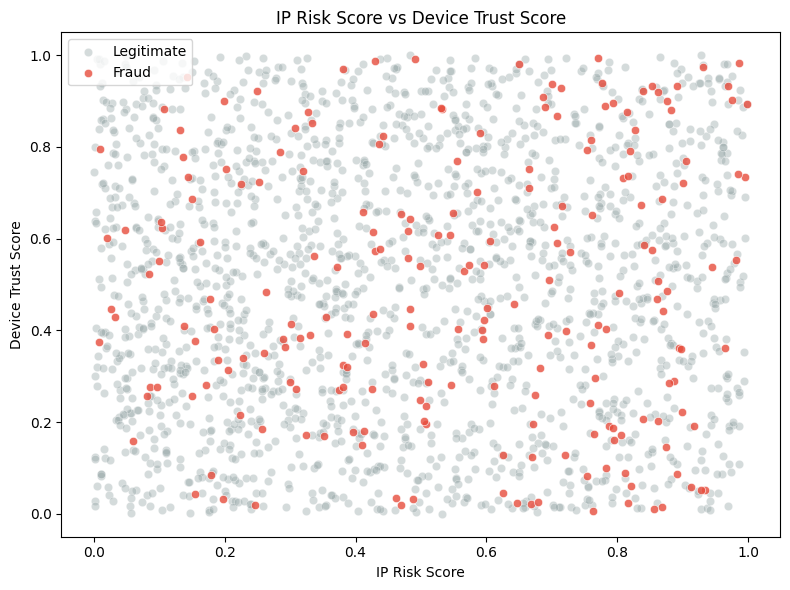

In [75]:
df_sample = df.sample(2000, random_state=42)

plt.figure(figsize=(8,6))

# Plot Legitimate first
sns.scatterplot(
    data=df_sample[df_sample['is_fraud'] == 0],
    x='ip_address_risk_score',
    y='device_trust_score',
    color='#95a5a6',
    alpha=0.4,
    label='Legitimate'
)

# Plot Fraud on top
sns.scatterplot(
    data=df_sample[df_sample['is_fraud'] == 1],
    x='ip_address_risk_score',
    y='device_trust_score',
    color='#e74c3c',
    alpha=0.8,
    label='Fraud'
)

plt.xlabel('IP Risk Score')
plt.ylabel('Device Trust Score')
plt.title('IP Risk Score vs Device Trust Score')
plt.legend(title="")
plt.tight_layout()
plt.show()

### Fraud Count Device Change and Location Change

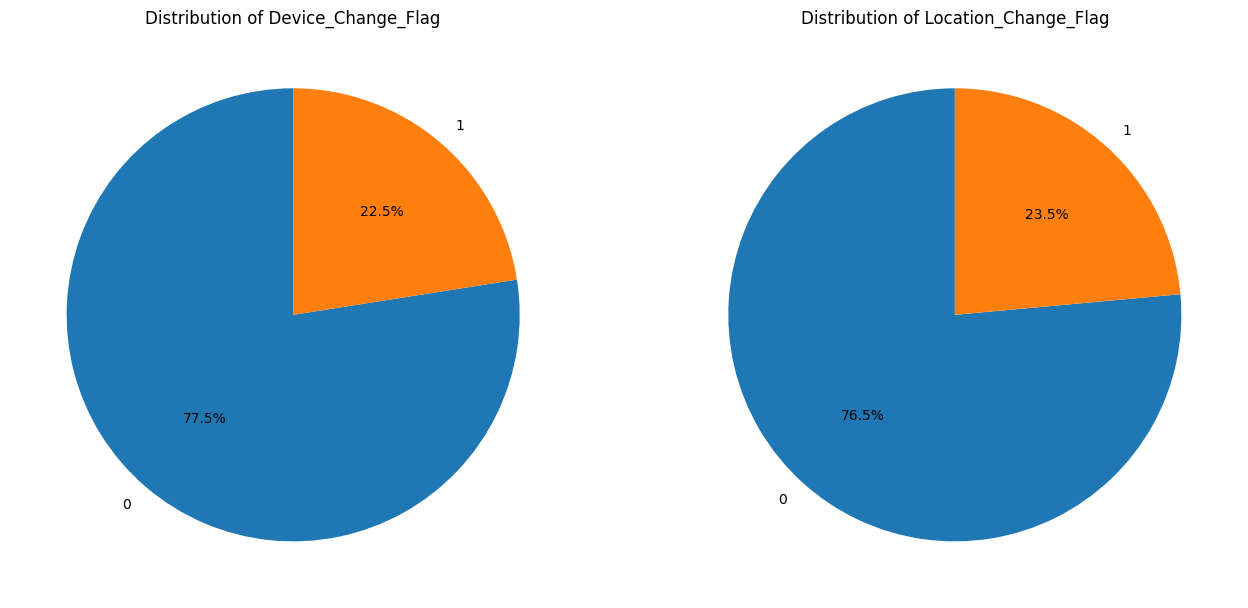

In [79]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for fraud device_change_flag and location_change_flag
for idx, col in enumerate(['device_change_flag','location_change_flag'], 1):
    ax = plt.subplot(2, 3, idx)
    fraud_df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {col.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

<Axes: xlabel='transaction_date', ylabel='avg_amount_last_24h'>

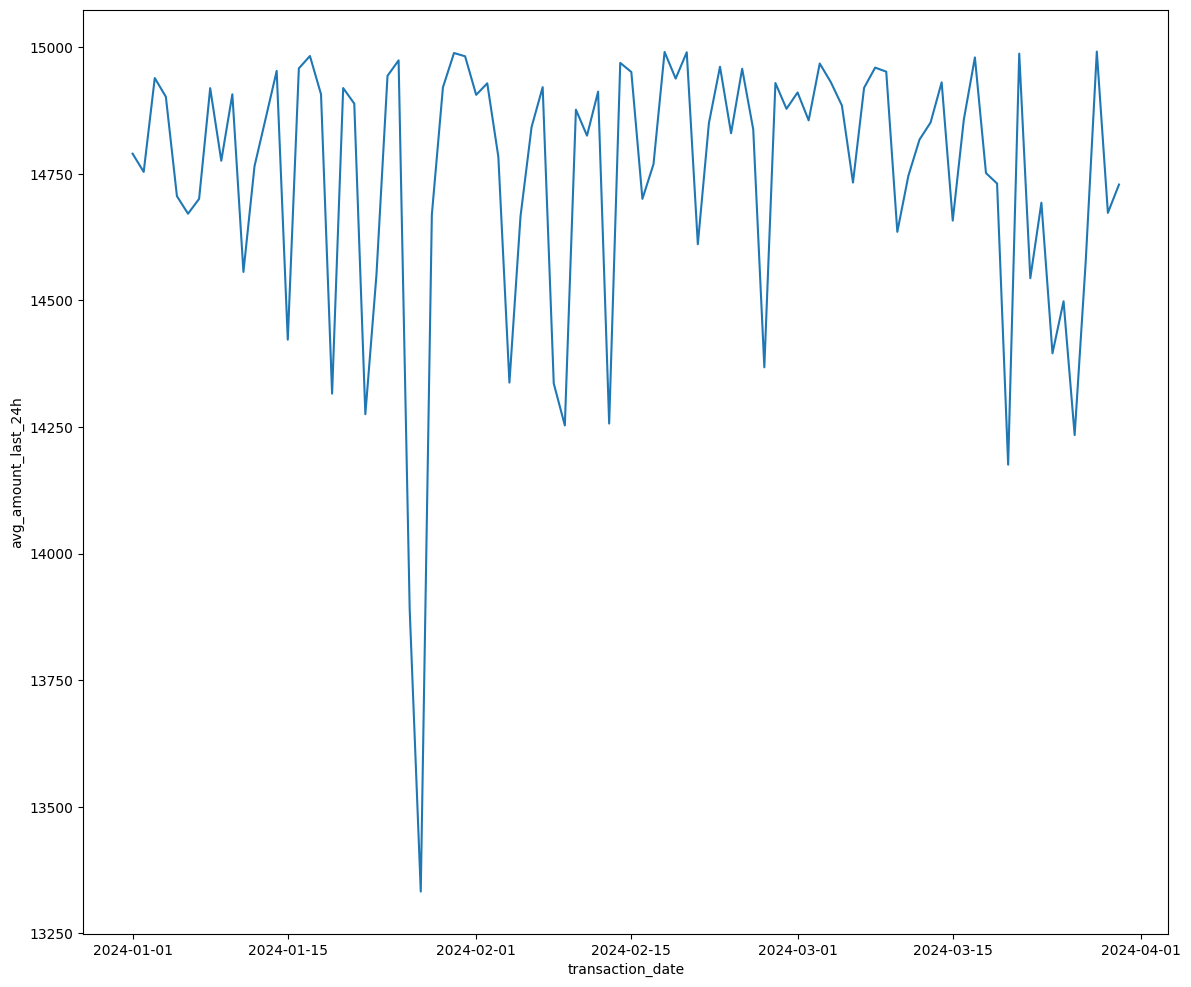

In [96]:
plt.figure(figsize=(14,12))
line = fraud_df.groupby('transaction_date')['avg_amount_last_24h'].max().reset_index()
sns.lineplot(data=line, x='transaction_date',y='avg_amount_last_24h')

In [91]:
fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5028 entries, 33 to 49989
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   transaction_id                  5028 non-null   int64         
 1   customer_id                     5028 non-null   int64         
 2   device_id                       5028 non-null   int64         
 3   merchant_id                     5028 non-null   int64         
 4   transaction_date                5028 non-null   datetime64[ns]
 5   transaction_time                5028 non-null   object        
 6   amount                          5028 non-null   float64       
 7   payment_method                  5028 non-null   object        
 8   is_international                5028 non-null   int64         
 9   merchant_category               5028 non-null   object        
 10  ip_address_risk_score           5028 non-null   float64       
 11  device_